# LiteALPR Demo
Welcome to the official demo for **LiteALPR**, an extremely fast and accurate License Plate Recognition system built on YOLOv8n-Efficient and SVTR26-Tiny. This notebook is designed to help you get started quickly.

In [4]:
!python --version

Python 3.8.10


In [ ]:
# Install PyTorch and Torchvision (CUDA 12.1 version)
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached sympy-1.13.3-py3-none-any.whl (6.2 MB)
  Using cached fsspec-2025.3.0-py3-none-any.whl (193 kB)
  Using cached filelock-3.16.1-py3-none-any.whl (16 kB)
  Using cached networkx-3.1-py3-none-any.whl (2.1 MB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl (14.9 MB)
  Using cached pillow-10.4.0-cp38-cp38-win_amd64.whl (2.6 MB)
  Using cached https://download.pytorch.org/whl/MarkupSafe-2.1.5-cp38-cp38-win_amd64.whl (17 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)


You should consider upgrading via the 'd:\ieee\data\phd\litealpr\.venv_38\scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import platform

import torch

# 1. Check CPU
print("=" * 45)
print(f"CPU: {platform.processor()}")

# 2. Check GPU / CUDA
print("=" * 45)
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name   : {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM    : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
else:
    print("PyTorch is running in CPU-only mode (CUDA not detected).")
print("=" * 45)

CPU: AMD64 Family 23 Model 96 Stepping 1, AuthenticAMD
CUDA Available: True
Device Name   : NVIDIA GeForce RTX 3060
Total VRAM    : 12.00 GB


In [3]:
# Install the necessary libraries
!pip install litealpr[gpu] huggingface_hub opencv-python matplotlib

  Using cached litealpr-0.1.3-py3-none-any.whl (55 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)
  Using cached matplotlib-3.7.5-cp38-cp38-win_amd64.whl (7.5 MB)
  Using cached requests-2.32.4-py3-none-any.whl (64 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
  Using cached PyYAML-6.0.3-cp38-cp38-win_amd64.whl (160 kB)
  Using cached importlib_resources-6.4.5-py3-none-any.whl (36 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached contourpy-1.1.1-cp38-cp38-win_amd64.whl (477 kB)
  Using cached pyparsing-3.1.4-py3-none-any.whl (104 kB)
  Using cached fonttools-4.57.0-cp38-cp38-win_amd64.whl (1.5 MB)
  Using cached kiwisolver-1.4.7-cp38-cp38-win_amd64.whl (55 kB)
  Using cached onnx-1.17.0-cp38-cp38-win_amd64.whl (14.5 MB)
  Using cached huggingface_hub-0.31.0-py3-none-any.whl (484 kB)
  Using cached ultralytics-8.3.99-py3-none-any.whl (976 kB)
  Using cached onnx

You should consider upgrading via the 'd:\ieee\data\phd\litealpr\.venv_38\scripts\python.exe -m pip install --upgrade pip' command.


## 1. Import and Initialize
The `LiteALPR` class will automatically download the pre-trained weights (`YOLOv8n-Efficient` and `SVTR26-Tiny`) from Hugging Face if you don't provide local paths.

In [7]:
import cv2
import matplotlib.pyplot as plt

from litealpr import LiteALPR

# Initialize the End-to-End Pipeline
model = LiteALPR(device='cuda:0') # Use 'cpu' if you want to use CPU

[LiteALPR] Initializing on cuda:0...
[LiteALPR] Downloading/Verifying yolov8n_efficient/best_416.onnx from HuggingFace...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


[LiteALPR] Loading Detection Model: C:\Users\ADMIN\.cache\huggingface\hub\models--anhone3--LiteALPR\snapshots\efddb217184a7b0de9e5ca5f17072221e3bc6c6d\yolov8n_efficient\best_416.onnx
[LiteALPR] Downloading/Verifying svtr26_tiny/best.onnx from HuggingFace...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


[LiteALPR] Loading Recognition Model: C:\Users\ADMIN\.cache\huggingface\hub\models--anhone3--LiteALPR\snapshots\efddb217184a7b0de9e5ca5f17072221e3bc6c6d\svtr26_tiny\best.onnx
[LiteALPR] Models loaded successfully!


## 2. Run Inference

In [10]:
results = model.read('../dataset/det/test/images/carlong_0178.png')
print("Detected License Plates:")
for res in results:
    print(f"Text: {res['text']} | Confidence: {res['score']:.2f} | BBox: {res['box']}")

Detected License Plates:
Text: 51G51332 | Confidence: 1.00 | BBox: [167, 229, 271, 262]


## 3. Visualize Results

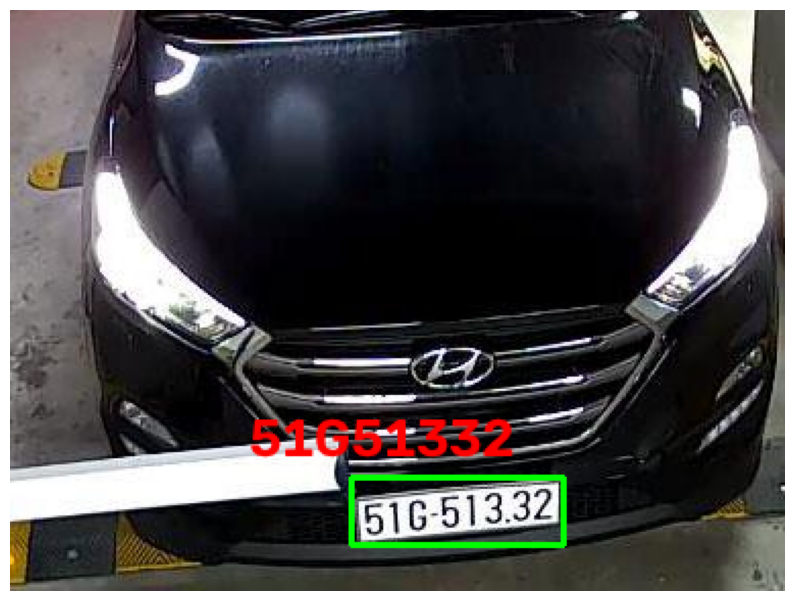

In [11]:
img = cv2.imread('../dataset/det/test/images/carlong_0178.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for res in results:
    x1, y1, x2, y2 = res['box']
    text = res['text']

    # Draw BBox
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Draw Text
    cv2.putText(img, text, (x1 - 50, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()